In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 29 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Year                       1000000 non-null  int64  
 1   Month                      1000000 non-null  int64  
 2   DayofMonth                 1000000 non-null  int64  
 3   FlightDate                 1000000 non-null  object 
 4   Marketing_Airline_Network  1000000 non-null  object 
 5   OriginCityName             1000000 non-null  object 
 6   DestCityName               1000000 non-null  object 
 7   CRSDepTime                 1000000 non-null  int64  
 8   DepTime                    1000000 non-null  float64
 9   DepDelay                   1000000 non-null  float64
 10  DepDelayMinutes            1000000 non-null  float64
 11  TaxiOut                    1000000 non-null  float64
 12  WheelsOff                  1000000 non-null  float64
 13  WheelsOn     

In [4]:
df = df.rename(columns = 
          { "FlightDate": "flight_date",
            "OriginCityName": "origin_city_name", 
            "DestCityName": "dest_city_name",
            "CRSDepTime": "CRS_dep_time",
            "DepTime": "dep_time",
            "DepDelay": "dep_delay",
            "DepDelayMinutes": "dep_delay_minutes",
            "TaxiOut": "taxi_out",
            "WheelsOff": "wheels_off",
            "WheelsOn": "wheels_on",
            "TaxiIn": "taxi_in",
            "CRSArrTime": "CRS_arr_time",
            "ArrTime": "arr_time",
            "ArrDelay": "arr_delay",
            "ArrDelayMinutes": "arr_delay_minutes",
            "CRSElapsedTime": "CRS_elapsed_time",
            "ActualElapsedTime": "actual_elapsed_time",
            "AirTime": "air_time",
            "Distance": "distance",
            "DistanceGroup": "distance_group",
            "CarrierDelay": "carrier_delay",
            "WeatherDelay": "weather_delay",
            "NASDelay": "NAS_delay",
            "SecurityDelay": "security_delay",
            "LateAircraftDelay": "late_aircraft_delay",
            "DayofMonth": "day_of_month"
          }).copy()

In [5]:
# Convert flight_date column into datetime
df["flight_date"] = pd.to_datetime(df["flight_date"])

# Add week_of_day variable
df["day_of_week"] = df["flight_date"].dt.day_name()

# Add month variable
df["flight_month"] = df["flight_date"].dt.month

# Add categorical variable for to identify time-period
df["dep_period"] = pd.cut(x = df["CRS_dep_time"], bins = [0, 600, 1200, 1800, 2359],\
                           labels = ["Midnight", "Morning", "Afternoon", "Night"])

df["arr_period"] = pd.cut(x = df["CRS_arr_time"], bins = [0, 600, 1200, 1800, 2359],\
                           labels = ["Midnight", "Morning", "Afternoon", "Night"])

In [6]:
def airline_abbreviation_to_name(x): 
    airline_abb = {
        "WN" : "Southwest Airlines"  
    }
    for key, value in airline_abb.items():
        if x == key:
            x = value
    return x

df["Airline"] = df["Marketing_Airline_Network"].apply(airline_abbreviation_to_name)

In [7]:
# Check for duplicate data
df.loc[df.duplicated()]
# Drop the Marketing_Airline_Network column
df = df.drop(columns = "Marketing_Airline_Network")
df.head()

,Year,Month,day_of_month,flight_date,origin_city_name,dest_city_name,CRS_dep_time,dep_time,dep_delay,dep_delay_minutes,...,carrier_delay,weather_delay,NAS_delay,security_delay,late_aircraft_delay,day_of_week,flight_month,dep_period,arr_period,Airline
0,2018,5,13,2018-05-13,"Newark, NJ","Fort Lauderdale, FL",1105,1139.0,34.0,34.0,...,0.0,0.0,17.0,0.0,34.0,Sunday,5,Morning,Afternoon,Southwest Airlines
1,2020,2,3,2020-02-03,"Dallas/Fort Worth, TX","New York, NY",1707,1721.0,14.0,14.0,...,0.0,0.0,0.0,0.0,0.0,Monday,2,Afternoon,Night,Southwest Airlines
2,2020,1,9,2020-01-09,"Philadelphia, PA","Syracuse, NY",1650,1645.0,-5.0,0.0,...,0.0,0.0,0.0,0.0,0.0,Thursday,1,Afternoon,Night,Southwest Airlines
3,2019,3,29,2019-03-29,"Las Vegas, NV","Seattle, WA",2040,2028.0,-12.0,0.0,...,0.0,0.0,0.0,0.0,0.0,Friday,3,Night,Night,Southwest Airlines
4,2020,3,7,2020-03-07,"Dallas, TX","Birmingham, AL",1255,1331.0,36.0,36.0,...,20.0,0.0,0.0,0.0,0.0,Saturday,3,Afternoon,Afternoon,Southwest Airlines


In [8]:
def outlier_stat(serise):
    if isinstance(serise, pd.Series):
        Q1 = serise.quantile(0.25)
        Q3 = serise.quantile(0.75)
        IQR = Q3 - Q1
        higher_bond = Q3 + 1.5 * IQR
        lower_bond = Q1 - 1.5 * IQR
        return Q1, Q3, IQR,lower_bond, higher_bond
    else:
        raise TypeError("The argument passed in is not pandas series")

In [9]:
df_15 = df[(df["arr_delay_minutes"] < 15) & (df["arr_delay_minutes"] > 0)]

In [10]:
df_15.shape

(0, 33)

In [11]:
del df_15

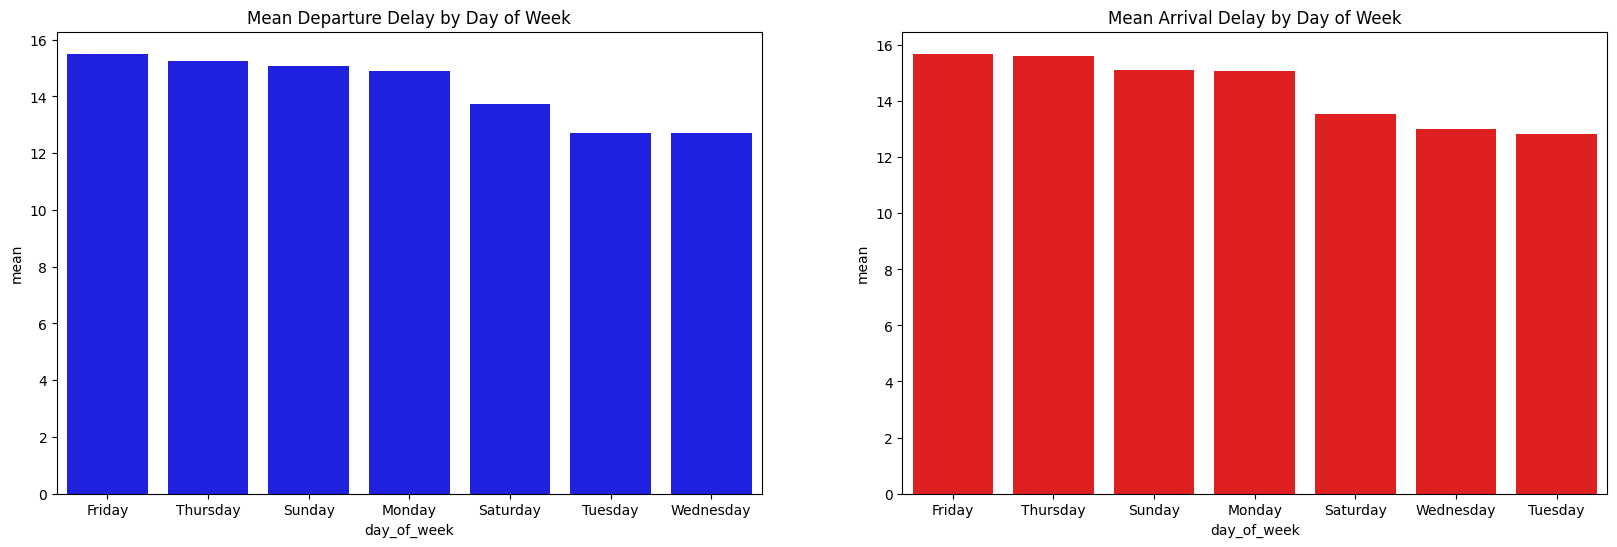

In [12]:
df_day_of_week_arr = df.groupby("day_of_week")["arr_delay_minutes"].describe()\
.sort_values(by = "mean", ascending = False)

df_day_of_week_dep = df.groupby("day_of_week")["dep_delay_minutes"].describe()\
.sort_values(by = "mean", ascending = False)

# create subplots
plt.figure(figsize = (20,6))
plt.subplot(1,2,1)
# mean departure delay by day of week
sns.barplot(data = df_day_of_week_dep.reset_index(), x = "day_of_week", y = "mean", color = "b")
plt.title("Mean Departure Delay by Day of Week")
plt.subplot(1,2,2)
# mean arrival delay by day of week
sns.barplot(data = df_day_of_week_arr.reset_index(), x = "day_of_week", y = "mean", color = "r")
plt.title("Mean Arrival Delay by Day of Week")
plt.show()
